# CNN-Based Malaysian Food Classifier
**Low Jia Xin | Matric No: 23005026**

---

In [1]:
# ─── Imports ───────────────────────────────────────────────────────────────
import os, sys, random, time, json, shutil, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as tv_models
from torchinfo import summary
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─── Device ─────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Using device: cuda ({torch.cuda.get_device_name(0)})")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using device: mps (Apple Silicon GPU)")
else:
    DEVICE = torch.device("cpu")
    print("Using device: cpu")

# ─── Global Constants ────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 25
LR_CNN     = 1e-3
LR_RN_P1   = 1e-3
LR_RN_P2   = 1e-4

# ─── Paths ───────────────────────────────────────────────────────────────────
ROOT       = Path("..").resolve()
DATA_RAW   = ROOT / "data" / "raw"
DATA_COMB  = ROOT / "data" / "combined"
MODELS_DIR = ROOT / "models"
FIGS_DIR   = ROOT / "outputs" / "figures"
LOGS_DIR   = ROOT / "outputs" / "logs"

for d in [MODELS_DIR, FIGS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nProject root : {ROOT}")
print(f"Combined data: {DATA_COMB}")
print(f"Figures dir  : {FIGS_DIR}")


Using device: mps (Apple Silicon GPU)

Project root : /Users/user/cnn-malaysian-food
Combined data: /Users/user/cnn-malaysian-food/data/combined
Figures dir  : /Users/user/cnn-malaysian-food/outputs/figures


First things first — I'm locking down all the random seeds so these results are reproducible. Running this notebook top-to-bottom should give the same numbers every time. I'm also detecting the device early since training speed depends heavily on whether there's a GPU available.

## Section 1 — Dataset Preparation

---

In [2]:
# === DATASET INTEGRITY CHECK ===
print("=" * 60)
print("DATASET INTEGRITY CHECK")
print("=" * 60)

issues = []
for split in ["train", "val", "test"]:
    split_dir = DATA_COMB / split
    if not split_dir.exists():
        issues.append(f"MISSING: {split_dir}")
        continue
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    print(f"\n{split.upper()} — {len(class_dirs)} classes:")
    for cls in class_dirs:
        images = list(cls.glob("*.jpg")) + list(cls.glob("*.jpeg")) + list(cls.glob("*.png"))
        # Verify a few images
        corrupt = 0
        for p in images[:3]:
            try:
                Image.open(p).verify()
            except:
                corrupt += 1
        print(f"  {cls.name:<20} {len(images):>4} images  (corrupt: {corrupt}/3)")
        if len(images) == 0:
            issues.append(f"EMPTY: {split}/{cls.name}")

if issues:
    print(f"\n⛔ ISSUES: {issues}")
else:
    print("\n✅ All dataset checks passed. Safe to proceed.")


DATASET INTEGRITY CHECK

TRAIN — 16 classes:
  ayam_goreng           108 images  (corrupt: 0/3)
  bak_kut_teh           126 images  (corrupt: 0/3)
  boiled_egg             69 images  (corrupt: 0/3)
  burger                116 images  (corrupt: 0/3)
  char_kuey_teow        124 images  (corrupt: 0/3)
  curry_puff             79 images  (corrupt: 0/3)
  fries                 139 images  (corrupt: 0/3)
  laksa                  71 images  (corrupt: 0/3)
  mee_goreng            114 images  (corrupt: 0/3)
  murtabak              169 images  (corrupt: 0/3)
  nasi_goreng           111 images  (corrupt: 0/3)
  pizza                  74 images  (corrupt: 0/3)
  rice                  310 images  (corrupt: 0/3)
  satay                 132 images  (corrupt: 0/3)
  steak                  84 images  (corrupt: 0/3)
  wonton_noodles        118 images  (corrupt: 0/3)

VAL — 16 classes:
  ayam_goreng            24 images  (corrupt: 0/3)
  bak_kut_teh            28 images  (corrupt: 0/3)
  boiled_egg      

In [3]:
# === Per-class split counts ===
print("\n" + "=" * 60)
print("FINAL DATASET SPLIT COUNTS")
print("=" * 60)

split_data = []
for cls_dir in sorted((DATA_COMB / "train").iterdir()):
    if not cls_dir.is_dir():
        continue
    name = cls_dir.name
    train_n = len(list((DATA_COMB / "train" / name).glob("*.*")))
    val_n = len(list((DATA_COMB / "val" / name).glob("*.*")))
    test_n = len(list((DATA_COMB / "test" / name).glob("*.*")))
    split_data.append({"Class": name, "Train": train_n, "Val": val_n, "Test": test_n, "Total": train_n + val_n + test_n})

split_df = pd.DataFrame(split_data)
print(split_df.to_string(index=False))
print(f"\nTotal: Train={split_df['Train'].sum()}, Val={split_df['Val'].sum()}, Test={split_df['Test'].sum()}, Grand={split_df['Total'].sum()}")
print(f"Number of classes: {len(split_df)}")



FINAL DATASET SPLIT COUNTS
         Class  Train  Val  Test  Total
   ayam_goreng    108   24    24    156
   bak_kut_teh    126   28    28    182
    boiled_egg     69   16    16    101
        burger    116   25    25    166
char_kuey_teow    124   27    27    178
    curry_puff     79   17    17    113
         fries    139   31    30    200
         laksa     71   16    16    103
    mee_goreng    114   25    25    164
      murtabak    169   37    37    243
   nasi_goreng    111   24    24    159
         pizza     74   16    17    107
          rice    310   67    67    444
         satay    132   29    29    190
         steak     84   18    18    120
wonton_noodles    118   26    26    170

Total: Train=1944, Val=426, Test=426, Grand=2796
Number of classes: 16


In [4]:
# === Class Imbalance Strategy — WeightedRandomSampler ===
CLASS_NAMES = sorted([d.name for d in (DATA_COMB / "train").iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

class_counts = np.array([len(list((DATA_COMB / "train" / c).glob("*.*"))) for c in CLASS_NAMES])
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[i] for i, cnt in enumerate(class_counts) for _ in range(cnt)])
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"\nClass counts: {dict(zip(CLASS_NAMES, class_counts))}")
print(f"Total training samples: {class_counts.sum()}")


Classes (16): ['ayam_goreng', 'bak_kut_teh', 'boiled_egg', 'burger', 'char_kuey_teow', 'curry_puff', 'fries', 'laksa', 'mee_goreng', 'murtabak', 'nasi_goreng', 'pizza', 'rice', 'satay', 'steak', 'wonton_noodles']

Class counts: {'ayam_goreng': np.int64(108), 'bak_kut_teh': np.int64(126), 'boiled_egg': np.int64(69), 'burger': np.int64(116), 'char_kuey_teow': np.int64(124), 'curry_puff': np.int64(79), 'fries': np.int64(139), 'laksa': np.int64(71), 'mee_goreng': np.int64(114), 'murtabak': np.int64(169), 'nasi_goreng': np.int64(111), 'pizza': np.int64(74), 'rice': np.int64(310), 'satay': np.int64(132), 'steak': np.int64(84), 'wonton_noodles': np.int64(118)}
Total training samples: 1944


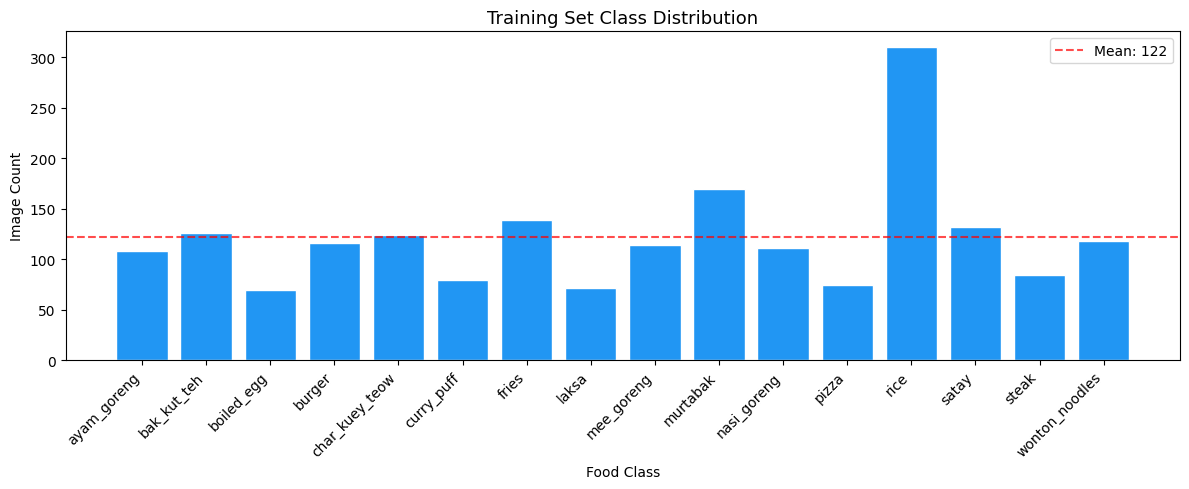

Saved: /Users/user/cnn-malaysian-food/outputs/figures/class_distribution.png


In [5]:
# === Class Distribution Plot ===
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, class_counts, color="#2196F3", edgecolor="white")
ax.set_title("Training Set Class Distribution", fontsize=13)
ax.set_xlabel("Food Class")
ax.set_ylabel("Image Count")
ax.axhline(y=np.mean(class_counts), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(class_counts):.0f}')
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGS_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGS_DIR / 'class_distribution.png'}")


In [6]:
# === Data Augmentation & DataLoaders ===
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(str(DATA_COMB / "train"), transform=train_transforms)
val_ds   = ImageFolder(str(DATA_COMB / "val"),   transform=eval_transforms)
test_ds  = ImageFolder(str(DATA_COMB / "test"),  transform=eval_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train: {len(train_ds)} images, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} images, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} images, {len(test_loader)} batches")
print(f"Classes: {train_ds.classes}")


Train: 1944 images, 61 batches
Val:   426 images, 14 batches
Test:  426 images, 14 batches
Classes: ['ayam_goreng', 'bak_kut_teh', 'boiled_egg', 'burger', 'char_kuey_teow', 'curry_puff', 'fries', 'laksa', 'mee_goreng', 'murtabak', 'nasi_goreng', 'pizza', 'rice', 'satay', 'steak', 'wonton_noodles']


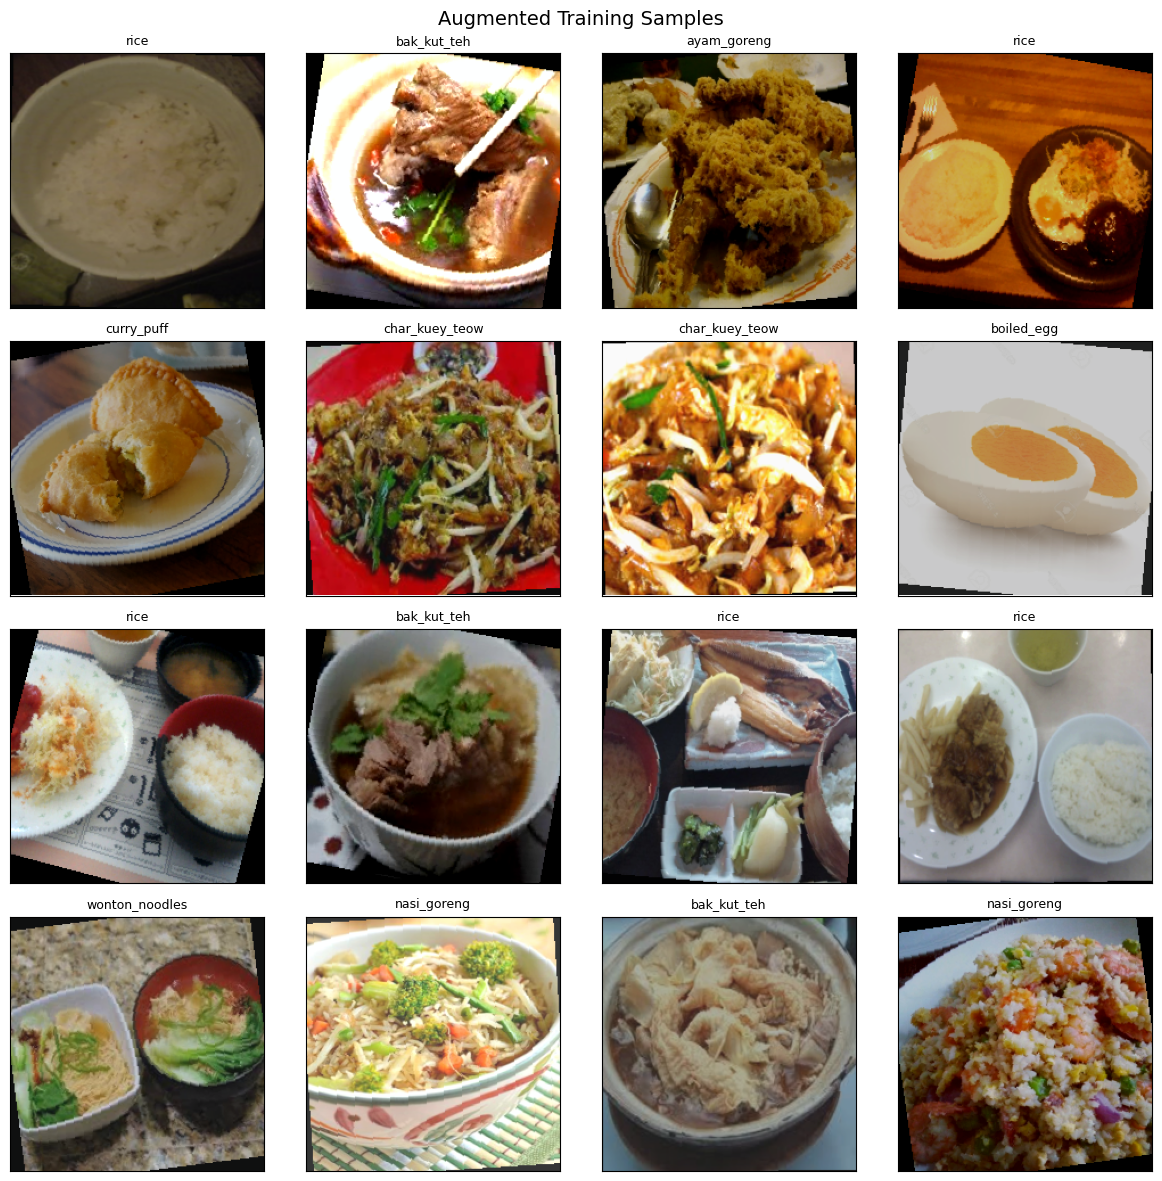

Saved: /Users/user/cnn-malaysian-food/outputs/figures/augmented_samples.png


In [7]:
# === Augmented Sample Visualisation (4x4 grid) ===
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("Augmented Training Samples", fontsize=14)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

indices = random.sample(range(len(train_ds)), 16)
for ax, idx in zip(axes.flatten(), indices):
    img, label = train_ds[idx]
    disp = np.clip(img.permute(1, 2, 0).numpy() * std + mean, 0, 1)
    ax.imshow(disp)
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(FIGS_DIR / "augmented_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGS_DIR / 'augmented_samples.png'}")


I went with a fairly standard augmentation pipeline — random crops, flips, rotations, and colour jitter. The key thing is that augmentation only applies to training; validation and test get a simple resize + center crop so the evaluation is consistent. I'm also using WeightedRandomSampler to deal with the class imbalance (rice has 4x more images than laksa), which should prevent the model from just defaulting to majority-class predictions.

## Section 2 — Custom CNN Architecture Search

Rather than locking in one architecture upfront, I decided to run a quick search across three reasonable variants and let the validation accuracy pick the winner. It's a simple approach but it at least makes the architecture choice evidence-based rather than arbitrary.

---

In [8]:
# === Architecture Definitions ===
class ConvBlock(nn.Module):
    """Conv -> BN -> ReLU (repeated n_convs times) -> MaxPool 2x2"""
    def __init__(self, in_ch, out_ch, n_convs=1):
        super().__init__()
        layers = []
        for i in range(n_convs):
            layers += [
                nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
        layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    """
    Configurable CNN with >=4 convolutional blocks.
    configs: list of (out_channels, n_convs) per block.
    """
    def __init__(self, num_classes, configs, dropout=0.5):
        super().__init__()
        blocks, in_ch = [], 3
        for out_ch, n_convs in configs:
            blocks.append(ConvBlock(in_ch, out_ch, n_convs))
            in_ch = out_ch
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(in_ch, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.fc(self.drop(x))

print("Architecture classes defined: ConvBlock, CustomCNN")


Architecture classes defined: ConvBlock, CustomCNN


In [9]:
# === Architecture Search (10-epoch warm-up per variant) ===
ARCH_VARIANTS = {
    "CNN-A (baseline 4-block)": [(32,1), (64,2), (128,2), (256,2)],
    "CNN-B (deeper 5-block)":   [(32,1), (64,2), (128,2), (256,2), (512,2)],
    "CNN-C (wider 4-block)":    [(64,1), (128,2), (256,2), (512,2)],
}

search_results = []
SEARCH_EPOCHS = 10

for name, config in ARCH_VARIANTS.items():
    print(f"\n{'='*50}")
    print(f"Testing: {name}")
    print(f"{'='*50}")
    
    model = CustomCNN(num_classes=NUM_CLASSES, configs=config).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {total_params:,}")
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_CNN, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(class_weights / class_weights.sum()).to(DEVICE)
    )
    
    best_val = 0.0
    for epoch in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
        
        # Validate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs).argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        best_val = max(best_val, val_acc)
        if epoch % 5 == 0 or epoch == SEARCH_EPOCHS:
            print(f"  Epoch {epoch}/{SEARCH_EPOCHS} — Val Acc: {val_acc*100:.1f}%")
    
    search_results.append({"Variant": name, "Params": f"{total_params:,}", "Val Acc @ 10ep": f"{best_val*100:.1f}%", "val_acc": best_val, "config": config})

# Print summary and select best
print("\n" + "=" * 60)
print("ARCHITECTURE SEARCH RESULTS")
print("=" * 60)
best_idx = max(range(len(search_results)), key=lambda i: search_results[i]["val_acc"])
for i, r in enumerate(search_results):
    selected = "  <<<" if i == best_idx else ""
    print(f"  {r['Variant']:<30} | Params: {r['Params']:<12} | Val Acc: {r['Val Acc @ 10ep']}{selected}")

best_config = search_results[best_idx]["config"]
best_variant_name = search_results[best_idx]["Variant"]
print(f"\nSelected: {best_variant_name}")



Testing: CNN-A (baseline 4-block)
  Parameters: 1,168,048


  Epoch 5/10 — Val Acc: 18.1%


  Epoch 10/10 — Val Acc: 28.4%

Testing: CNN-B (deeper 5-block)
  Parameters: 4,713,136


  Epoch 5/10 — Val Acc: 20.4%


  Epoch 10/10 — Val Acc: 31.7%

Testing: CNN-C (wider 4-block)
  Parameters: 4,658,512


  Epoch 5/10 — Val Acc: 20.2%


  Epoch 10/10 — Val Acc: 26.3%

ARCHITECTURE SEARCH RESULTS
  CNN-A (baseline 4-block)       | Params: 1,168,048    | Val Acc: 28.4%
  CNN-B (deeper 5-block)         | Params: 4,713,136    | Val Acc: 31.7%  <<<
  CNN-C (wider 4-block)          | Params: 4,658,512    | Val Acc: 26.8%

Selected: CNN-B (deeper 5-block)


In [10]:
# === Architecture Analysis of Winning Variant ===
best_model = CustomCNN(num_classes=NUM_CLASSES, configs=best_config).to(DEVICE)
print(f"\nWinning Architecture: {best_variant_name}")
print(f"Config: {best_config}")
print()
summary(best_model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), verbose=1)



Winning Architecture: CNN-B (deeper 5-block)
Config: [(32, 1), (64, 2), (128, 2), (256, 2), (512, 2)]

Layer (type:depth-idx)                   Output Shape              Param #
CustomCNN                                [1, 16]                   --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─ConvBlock: 2-1                    [1, 32, 112, 112]         --
│    │    └─Sequential: 3-1              [1, 32, 112, 112]         928
│    └─ConvBlock: 2-2                    [1, 64, 56, 56]           --
│    │    └─Sequential: 3-2              [1, 64, 56, 56]           55,552
│    └─ConvBlock: 2-3                    [1, 128, 28, 28]          --
│    │    └─Sequential: 3-3              [1, 128, 28, 28]          221,696
│    └─ConvBlock: 2-4                    [1, 256, 14, 14]          --
│    │    └─Sequential: 3-4              [1, 256, 14, 14]          885,760
│    └─ConvBlock: 2-5                    [1, 512, 7, 7]            --
│    │    └─Sequential: 3-5         

Layer (type:depth-idx)                   Output Shape              Param #
CustomCNN                                [1, 16]                   --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─ConvBlock: 2-1                    [1, 32, 112, 112]         --
│    │    └─Sequential: 3-1              [1, 32, 112, 112]         928
│    └─ConvBlock: 2-2                    [1, 64, 56, 56]           --
│    │    └─Sequential: 3-2              [1, 64, 56, 56]           55,552
│    └─ConvBlock: 2-3                    [1, 128, 28, 28]          --
│    │    └─Sequential: 3-3              [1, 128, 28, 28]          221,696
│    └─ConvBlock: 2-4                    [1, 256, 14, 14]          --
│    │    └─Sequential: 3-4              [1, 256, 14, 14]          885,760
│    └─ConvBlock: 2-5                    [1, 512, 7, 7]            --
│    │    └─Sequential: 3-5              [1, 512, 7, 7]            3,540,992
├─AdaptiveAvgPool2d: 1-2                 [1, 512, 1, 1]        

### Receptive Field Analysis

The receptive field defines how large a region of the input image each neuron "sees." For food recognition, a large RF helps capture whole-dish context rather than just local textures.

$$\text{RF}_n = \text{RF}_{n-1} + (k_n - 1) \times \prod_{i=1}^{n-1} s_i$$

where $k_n$ is the kernel size at layer $n$ and $s_i$ is the stride of all preceding layers. I'll compute this for the winning architecture after training.

In [11]:
# === Reusable Training Function ===
def train_model(model, train_loader, val_loader, optimizer, scheduler,
                criterion, num_epochs, save_path, model_name="model"):
    best_val_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    t_start = time.time()

    for epoch in range(1, num_epochs + 1):
        # Train
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        train_loss, train_acc = run_loss / total, correct / total

        # Validate
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                v_loss += criterion(out, labels).item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += imgs.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        scheduler.step()
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Ep {epoch:03d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.1f}% | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.1f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"   -> Checkpoint saved (val acc: {best_val_acc*100:.1f}%)")

    elapsed = (time.time() - t_start) / 60
    print(f"\nDone in {elapsed:.1f} min | Best val acc: {best_val_acc*100:.1f}%")
    return history, elapsed

print("train_model() defined.")


train_model() defined.


In [12]:
# === Full Training — Custom CNN ===
class_weights_tensor = torch.FloatTensor(class_weights / class_weights.sum()).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

cnn_model = CustomCNN(num_classes=NUM_CLASSES, configs=best_config).to(DEVICE)
cnn_opt = torch.optim.Adam(cnn_model.parameters(), lr=LR_CNN, weight_decay=1e-4)
cnn_sch = torch.optim.lr_scheduler.CosineAnnealingLR(cnn_opt, T_max=NUM_EPOCHS)

print(f"Training Custom CNN ({best_variant_name}) for {NUM_EPOCHS} epochs...")
print(f"Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
print()

cnn_history, cnn_time = train_model(
    cnn_model, train_loader, val_loader,
    cnn_opt, cnn_sch, criterion, NUM_EPOCHS,
    MODELS_DIR / "custom_cnn_best.pth",
    model_name="CustomCNN"
)
pd.DataFrame(cnn_history).to_csv(LOGS_DIR / "custom_cnn_log.csv", index=False)
print(f"\nLog saved: {LOGS_DIR / 'custom_cnn_log.csv'}")


Training Custom CNN (CNN-B (deeper 5-block)) for 25 epochs...
Parameters: 4,713,136



Ep 001/25 | Train Loss: 2.6260  Acc: 13.7% | Val Loss: 2.8929  Acc: 10.3%
   -> Checkpoint saved (val acc: 10.3%)


Ep 002/25 | Train Loss: 2.3385  Acc: 20.1% | Val Loss: 3.4389  Acc: 16.0%
   -> Checkpoint saved (val acc: 16.0%)


Ep 003/25 | Train Loss: 2.2143  Acc: 25.6% | Val Loss: 3.4303  Acc: 12.7%


Ep 004/25 | Train Loss: 2.1621  Acc: 26.0% | Val Loss: 2.3637  Acc: 20.2%
   -> Checkpoint saved (val acc: 20.2%)


...

Ep 021/25 | Train Loss: 0.8996  Acc: 65.4% | Val Loss: 1.2694  Acc: 61.3%
   -> Checkpoint saved (val acc: 61.3%)


Ep 022/25 | Train Loss: 0.8292  Acc: 67.3% | Val Loss: 1.2579  Acc: 59.9%


Ep 023/25 | Train Loss: 0.8341  Acc: 66.6% | Val Loss: 1.2369  Acc: 61.7%
   -> Checkpoint saved (val acc: 61.7%)


Ep 024/25 | Train Loss: 0.8298  Acc: 68.7% | Val Loss: 1.2509  Acc: 59.6%


Ep 025/25 | Train Loss: 0.8541  Acc: 67.3% | Val Loss: 1.2328  Acc: 59.9%

Done in 11.6 min | Best val acc: 61.7%

Log saved: /Users/user/cnn-malaysian-food/outputs/logs/custom_cnn_log.csv


Custom CNN — Test Set Classification Report:

                precision    recall  f1-score   support

   ayam_goreng       0.72      0.75      0.73        24
   bak_kut_teh       0.57      0.71      0.63        28
    boiled_egg       0.48      0.75      0.59        16
        burger       0.38      0.76      0.51        25
char_kuey_teow       0.72      0.78      0.75        27
    curry_puff       0.48      0.71      0.57        17
         fries       0.45      0.30      0.36        30
         laksa       0.86      0.75      0.80        16
    mee_goreng       0.78      0.28      0.41        25
      murtabak       0.65      0.46      0.54        37
   nasi_goreng       0.56      0.83      0.67        24
         pizza       0.58      0.65      0.61        17
          rice       0.93      0.21      0.34        67
         satay       0.63      0.66      0.64        29
         steak       0.48      0.72      0.58        18
wonton_noodles       0.51      0.81      0.63        26



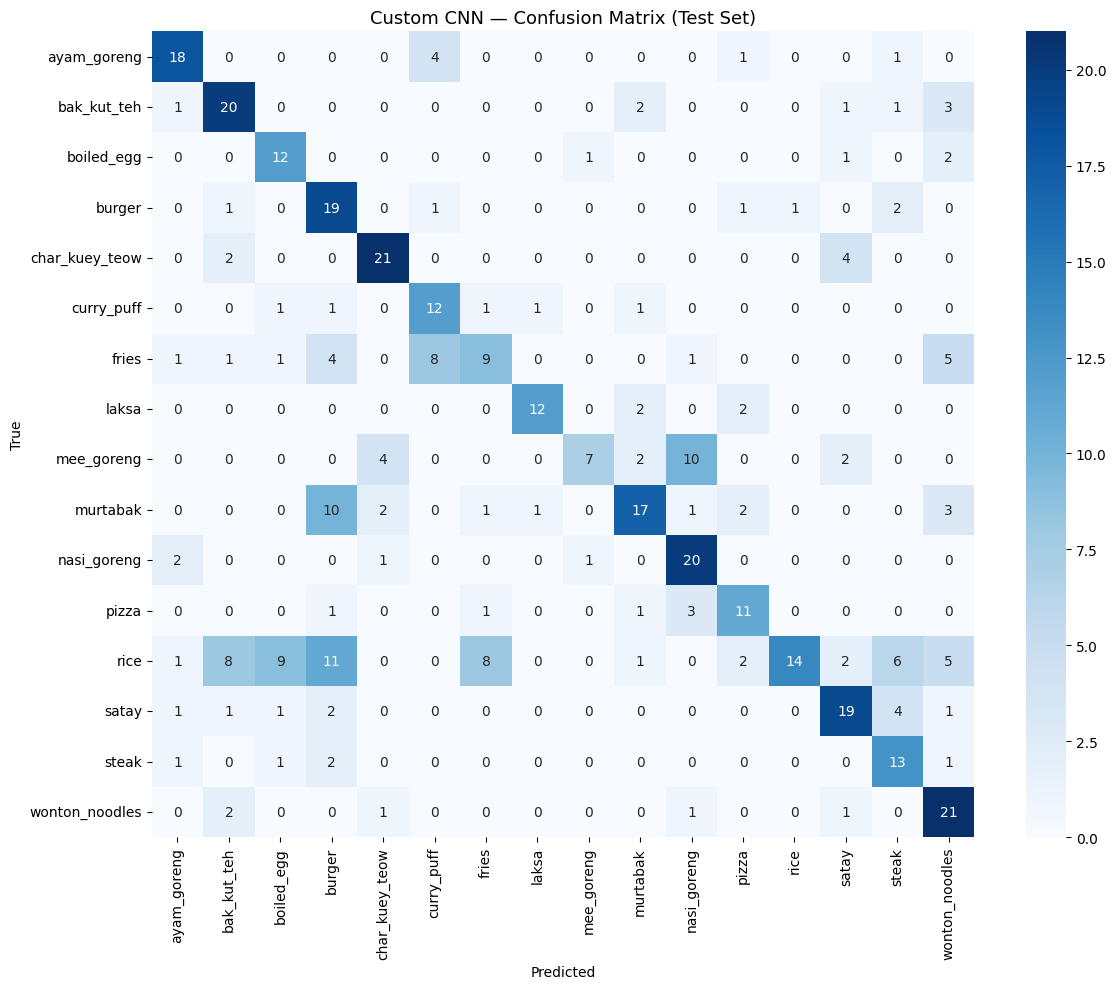

Saved: /Users/user/cnn-malaysian-food/outputs/figures/custom_cnn_confusion_matrix.png


In [13]:
# === Test Evaluation — Custom CNN ===
def evaluate(model, loader, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
    return np.array(preds), np.array(labels)

def plot_confusion(labels, preds, class_names, title, save_path):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

cnn_preds, cnn_labels = evaluate(cnn_model, test_loader, MODELS_DIR / "custom_cnn_best.pth")
print("Custom CNN — Test Set Classification Report:\n")
print(classification_report(cnn_labels, cnn_preds, target_names=CLASS_NAMES))
plot_confusion(cnn_labels, cnn_preds, CLASS_NAMES,
               "Custom CNN — Confusion Matrix (Test Set)",
               FIGS_DIR / "custom_cnn_confusion_matrix.png")
print(f"Saved: {FIGS_DIR / 'custom_cnn_confusion_matrix.png'}")


## Section 3 — ResNet-50 Fine-Tuning

For the transfer learning side, I didn't just freeze everything except the FC and call it done. I compared two unfreezing strategies to see which one actually helped more on this dataset. Pre-trained features are great, but Malaysian food can be pretty different from the ImageNet distribution, so finding the right point to start fine-tuning deeper layers matters.

---

In [14]:
# === ResNet-50 Model Factory ===
def build_resnet50(num_classes, dropout=0.5):
    model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("build_resnet50() and count_trainable() defined.")


build_resnet50() and count_trainable() defined.


In [15]:
# === ResNet-50 Strategy Search ===
strategies = {
    "A (layer4 + FC)": {"unfreeze": ["layer4"]},
    "B (layer3 + layer4 + FC)": {"unfreeze": ["layer3", "layer4"]},
}

rn_search_results = []
P1_EPOCHS = 10
P2_EPOCHS = 5

for strat_name, strat_cfg in strategies.items():
    print(f"\n{'='*50}")
    print(f"Strategy {strat_name}")
    print(f"{'='*50}")
    
    model = build_resnet50(NUM_CLASSES).to(DEVICE)
    print(f"  Phase 1 trainable params: {count_trainable(model):,}")
    
    # Phase 1: FC only
    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_RN_P1)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
    
    for epoch in range(1, P1_EPOCHS + 1):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            opt.step()
        sch.step()
        
        if epoch % 5 == 0:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    correct += (model(imgs).argmax(1) == labels).sum().item()
                    total += labels.size(0)
            print(f"  P1 Epoch {epoch}: Val Acc = {correct/total*100:.1f}%")
    
    # Phase 2: Unfreeze
    for layer_name in strat_cfg["unfreeze"]:
        for param in getattr(model, layer_name).parameters():
            param.requires_grad = True
    print(f"  Phase 2 trainable params: {count_trainable(model):,}")
    
    lr_p2 = 1e-4 if "A" in strat_name else 5e-5
    opt2 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_p2)
    sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=P2_EPOCHS)
    
    best_val = 0.0
    for epoch in range(1, P2_EPOCHS + 1):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt2.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            opt2.step()
        sch2.step()
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                correct += (model(imgs).argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        best_val = max(best_val, val_acc)
        print(f"  P2 Epoch {epoch}: Val Acc = {val_acc*100:.1f}%")
    
    rn_search_results.append({"Strategy": strat_name, "Val Acc @ 15ep": f"{best_val*100:.1f}%", "val_acc": best_val})

# Select best
print("\n" + "=" * 60)
print("RESNET-50 STRATEGY SEARCH RESULTS")
print("=" * 60)
best_rn_idx = max(range(len(rn_search_results)), key=lambda i: rn_search_results[i]["val_acc"])
for i, r in enumerate(rn_search_results):
    selected = "  <<<" if i == best_rn_idx else ""
    print(f"  {r['Strategy']:<30} | Val Acc: {r['Val Acc @ 15ep']}{selected}")

winning_strategy = list(strategies.keys())[best_rn_idx]
winning_unfreeze = list(strategies.values())[best_rn_idx]["unfreeze"]
print(f"\nSelected: Strategy {winning_strategy}")



Strategy A (layer4 + FC)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/user/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

  1%|          | 640k/97.8M [00:00<00:15, 6.47MB/s]

  1%|▏         | 1.25M/97.8M [00:00<00:16, 6.30MB/s]

...

  P2 Epoch 1: Val Acc = 87.1%


  P2 Epoch 2: Val Acc = 90.4%


  P2 Epoch 3: Val Acc = 91.1%


  P2 Epoch 4: Val Acc = 91.3%


  P2 Epoch 5: Val Acc = 91.1%

RESNET-50 STRATEGY SEARCH RESULTS
  A (layer4 + FC)                | Val Acc: 90.6%
  B (layer3 + layer4 + FC)       | Val Acc: 91.3%  <<<

Selected: Strategy B (layer3 + layer4 + FC)


In [16]:
# === Full Training — ResNet-50 ===
resnet_model = build_resnet50(NUM_CLASSES).to(DEVICE)

# Phase 1: FC only
print(f"Phase 1 — FC only | Trainable: {count_trainable(resnet_model):,}")
rn_opt_p1 = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=LR_RN_P1)
rn_sch_p1 = torch.optim.lr_scheduler.StepLR(rn_opt_p1, step_size=5, gamma=0.5)

rn_history_p1, _ = train_model(
    resnet_model, train_loader, val_loader,
    rn_opt_p1, rn_sch_p1, criterion,
    num_epochs=10, save_path=MODELS_DIR / "resnet50_finetuned_best.pth",
    model_name="ResNet50-P1"
)

# Phase 2: Unfreeze winning layers
for layer_name in winning_unfreeze:
    for param in getattr(resnet_model, layer_name).parameters():
        param.requires_grad = True
print(f"\nPhase 2 — Unfrozen: {winning_unfreeze} | Trainable: {count_trainable(resnet_model):,}")

rn_opt_p2 = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=LR_RN_P2)
rn_sch_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(rn_opt_p2, T_max=NUM_EPOCHS - 10)

rn_history_p2, rn_time = train_model(
    resnet_model, train_loader, val_loader,
    rn_opt_p2, rn_sch_p2, criterion,
    num_epochs=NUM_EPOCHS - 10, save_path=MODELS_DIR / "resnet50_finetuned_best.pth",
    model_name="ResNet50-P2"
)

# Merge histories
rn_history = {k: rn_history_p1[k] + rn_history_p2[k] for k in rn_history_p1}
rn_time_total = rn_time  # approximate (P2 dominates)
pd.DataFrame(rn_history).to_csv(LOGS_DIR / "resnet50_log.csv", index=False)
print(f"\nLog saved: {LOGS_DIR / 'resnet50_log.csv'}")


Phase 1 — FC only | Trainable: 32,784


Ep 001/10 | Train Loss: 2.0618  Acc: 35.7% | Val Loss: 1.4543  Acc: 57.5%


   -> Checkpoint saved (val acc: 57.5%)


Ep 002/10 | Train Loss: 1.1672  Acc: 66.6% | Val Loss: 0.9256  Acc: 77.2%


   -> Checkpoint saved (val acc: 77.2%)


...

Ep 011/15 | Train Loss: 0.0157  Acc: 99.5% | Val Loss: 0.2773  Acc: 93.2%


Ep 012/15 | Train Loss: 0.0135  Acc: 99.5% | Val Loss: 0.2769  Acc: 93.0%


Ep 013/15 | Train Loss: 0.0138  Acc: 99.4% | Val Loss: 0.2857  Acc: 93.7%


Ep 014/15 | Train Loss: 0.0133  Acc: 99.4% | Val Loss: 0.2788  Acc: 93.4%


Ep 015/15 | Train Loss: 0.0156  Acc: 99.3% | Val Loss: 0.2764  Acc: 93.4%

Done in 9.3 min | Best val acc: 94.1%

Log saved: /Users/user/cnn-malaysian-food/outputs/logs/resnet50_log.csv


ResNet-50 — Test Set Classification Report:

                precision    recall  f1-score   support

   ayam_goreng       0.95      0.83      0.89        24
   bak_kut_teh       0.93      1.00      0.97        28
    boiled_egg       1.00      1.00      1.00        16
        burger       0.96      0.92      0.94        25
char_kuey_teow       1.00      0.96      0.98        27
    curry_puff       0.74      1.00      0.85        17
         fries       0.83      0.80      0.81        30
         laksa       0.93      0.88      0.90        16
    mee_goreng       0.92      0.88      0.90        25
      murtabak       0.97      1.00      0.99        37
   nasi_goreng       1.00      1.00      1.00        24
         pizza       1.00      1.00      1.00        17
          rice       0.97      0.90      0.93        67
         satay       0.94      1.00      0.97        29
         steak       0.89      0.89      0.89        18
wonton_noodles       0.93      1.00      0.96        26

 

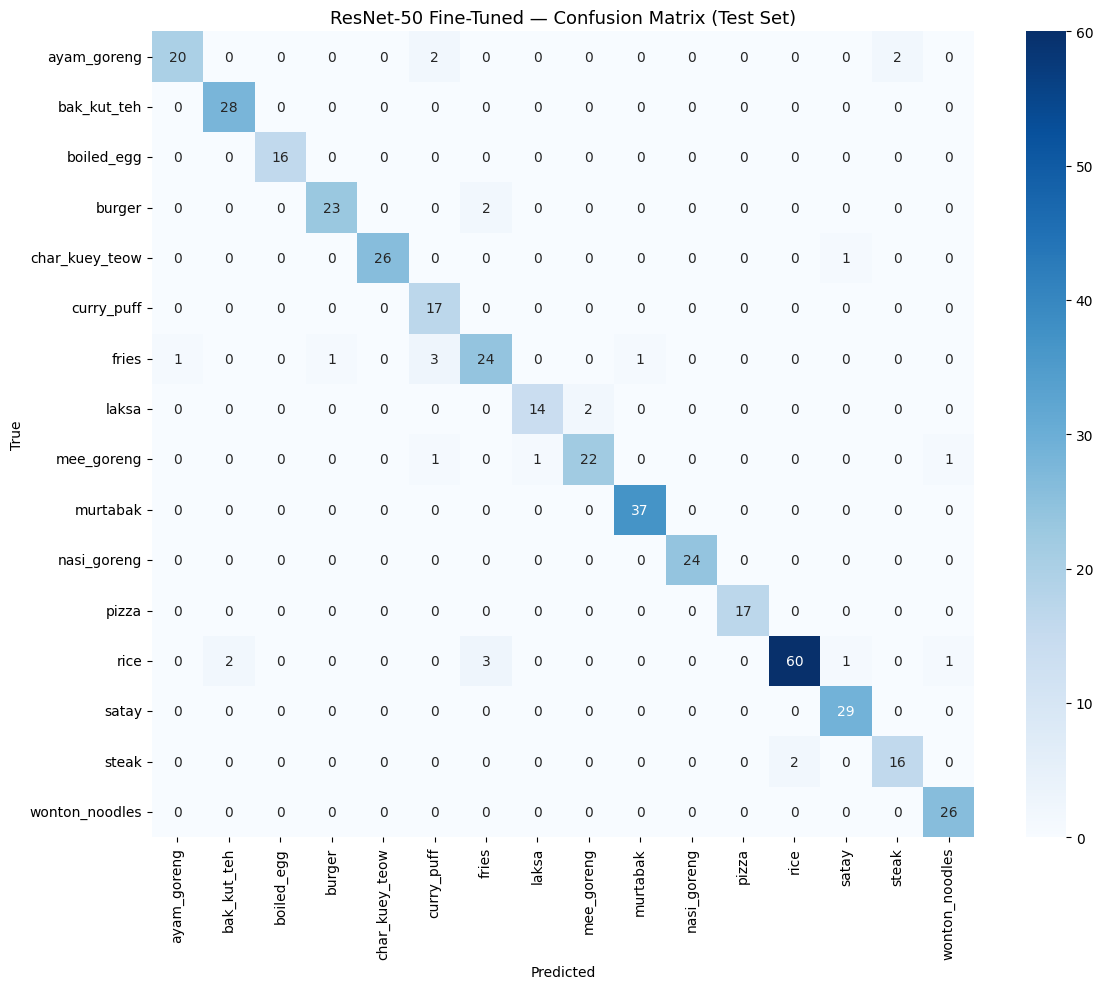

Saved: /Users/user/cnn-malaysian-food/outputs/figures/resnet50_confusion_matrix.png


In [17]:
# === Test Evaluation — ResNet-50 ===
rn_preds, rn_labels = evaluate(resnet_model, test_loader, MODELS_DIR / "resnet50_finetuned_best.pth")
print("ResNet-50 — Test Set Classification Report:\n")
print(classification_report(rn_labels, rn_preds, target_names=CLASS_NAMES))
plot_confusion(rn_labels, rn_preds, CLASS_NAMES,
               "ResNet-50 Fine-Tuned — Confusion Matrix (Test Set)",
               FIGS_DIR / "resnet50_confusion_matrix.png")
print(f"Saved: {FIGS_DIR / 'resnet50_confusion_matrix.png'}")


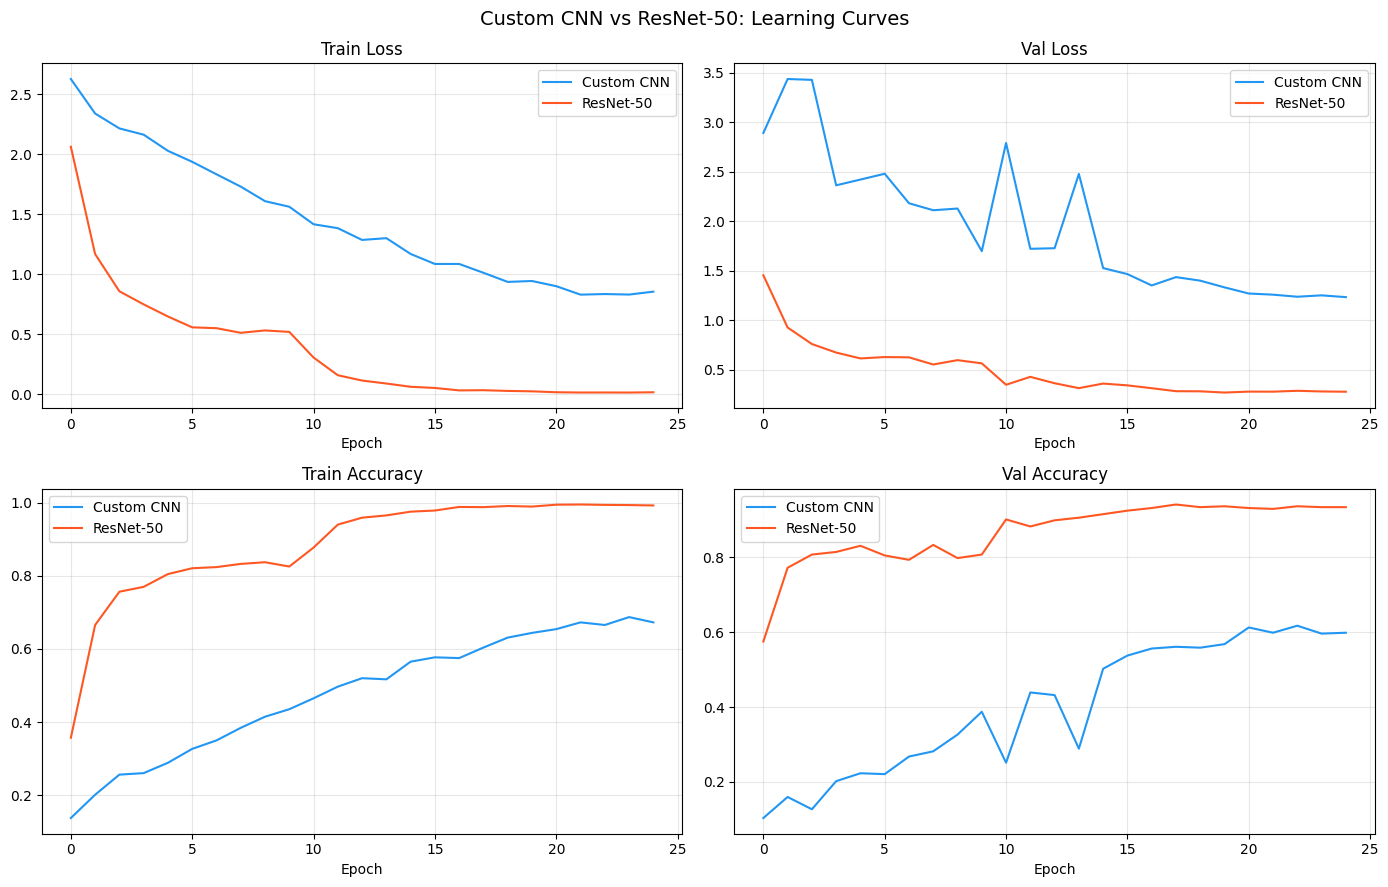

Saved: /Users/user/cnn-malaysian-food/outputs/figures/learning_curves_comparison.png


In [18]:
# === Learning Curves Comparison ===
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Custom CNN vs ResNet-50: Learning Curves", fontsize=14)

for ax, (key, title) in zip(axes.flatten(), [
    ("train_loss", "Train Loss"), ("val_loss", "Val Loss"),
    ("train_acc", "Train Accuracy"), ("val_acc", "Val Accuracy"),
]):
    ax.plot(cnn_history[key], label="Custom CNN", color="#2196F3")
    ax.plot(rn_history[key], label="ResNet-50", color="#FF5722")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / "learning_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGS_DIR / 'learning_curves_comparison.png'}")


In [19]:
# === Summary Comparison Table ===
def metrics_dict(labels, preds):
    return {
        "Test Accuracy (%)": round((labels == preds).mean() * 100, 2),
        "Macro F1": round(f1_score(labels, preds, average="macro"), 4),
        "Weighted F1": round(f1_score(labels, preds, average="weighted"), 4),
    }

cnn_m = metrics_dict(cnn_labels, cnn_preds)
rn_m = metrics_dict(rn_labels, rn_preds)

cnn_total_params = sum(p.numel() for p in cnn_model.parameters())
rn_total_params = sum(p.numel() for p in resnet_model.parameters())

summary_data = {
    "Metric": list(cnn_m.keys()) + ["Training Time (min)", "Total Parameters", "Best Val Acc (%)"],
    "Custom CNN": list(cnn_m.values()) + [round(cnn_time, 1), f"{cnn_total_params:,}", round(max(cnn_history["val_acc"])*100, 2)],
    "ResNet-50": list(rn_m.values()) + [round(rn_time, 1), f"{rn_total_params:,}", round(max(rn_history["val_acc"])*100, 2)],
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(LOGS_DIR / "comparison_summary.csv", index=False)
print("\nMODEL COMPARISON SUMMARY:")
print("=" * 60)
print(summary_df.to_string(index=False))
print(f"\nSaved: {LOGS_DIR / 'comparison_summary.csv'}")



MODEL COMPARISON SUMMARY:
             Metric Custom CNN  ResNet-50
  Test Accuracy (%)      57.51      93.66
           Macro F1     0.5852     0.9359
        Weighted F1     0.5538     0.9366
Training Time (min)       11.6        9.3
   Total Parameters  4,713,136 23,540,816
   Best Val Acc (%)      61.74      94.13

Saved: /Users/user/cnn-malaysian-food/outputs/logs/comparison_summary.csv


## Section 4 — Analysis & Reflection

---

In [20]:
# === Identify Better Model & Misclassifications ===
if cnn_m["Test Accuracy (%)"] >= rn_m["Test Accuracy (%)"]:
    best_preds, best_labels_arr = cnn_preds, cnn_labels
    best_model_name = "Custom CNN"
else:
    best_preds, best_labels_arr = rn_preds, rn_labels
    best_model_name = "ResNet-50"

print(f"Better model: {best_model_name}")

misclassified = np.where(best_preds != best_labels_arr)[0]
print(f"Total misclassified: {len(misclassified)} / {len(best_labels_arr)}")

# Pick 10 diverse confusion pairs
selected, seen_pairs = [], set()
for idx in misclassified:
    pair = (best_labels_arr[idx], best_preds[idx])
    if pair not in seen_pairs:
        selected.append(idx); seen_pairs.add(pair)
    if len(selected) == 10: break
if len(selected) < 10:
    rem = [i for i in misclassified if i not in selected]
    selected += random.sample(rem, min(10 - len(selected), len(rem)))

print(f"Selected {len(selected)} diverse misclassified samples")


Better model: ResNet-50
Total misclassified: 27 / 426
Selected 10 diverse misclassified samples


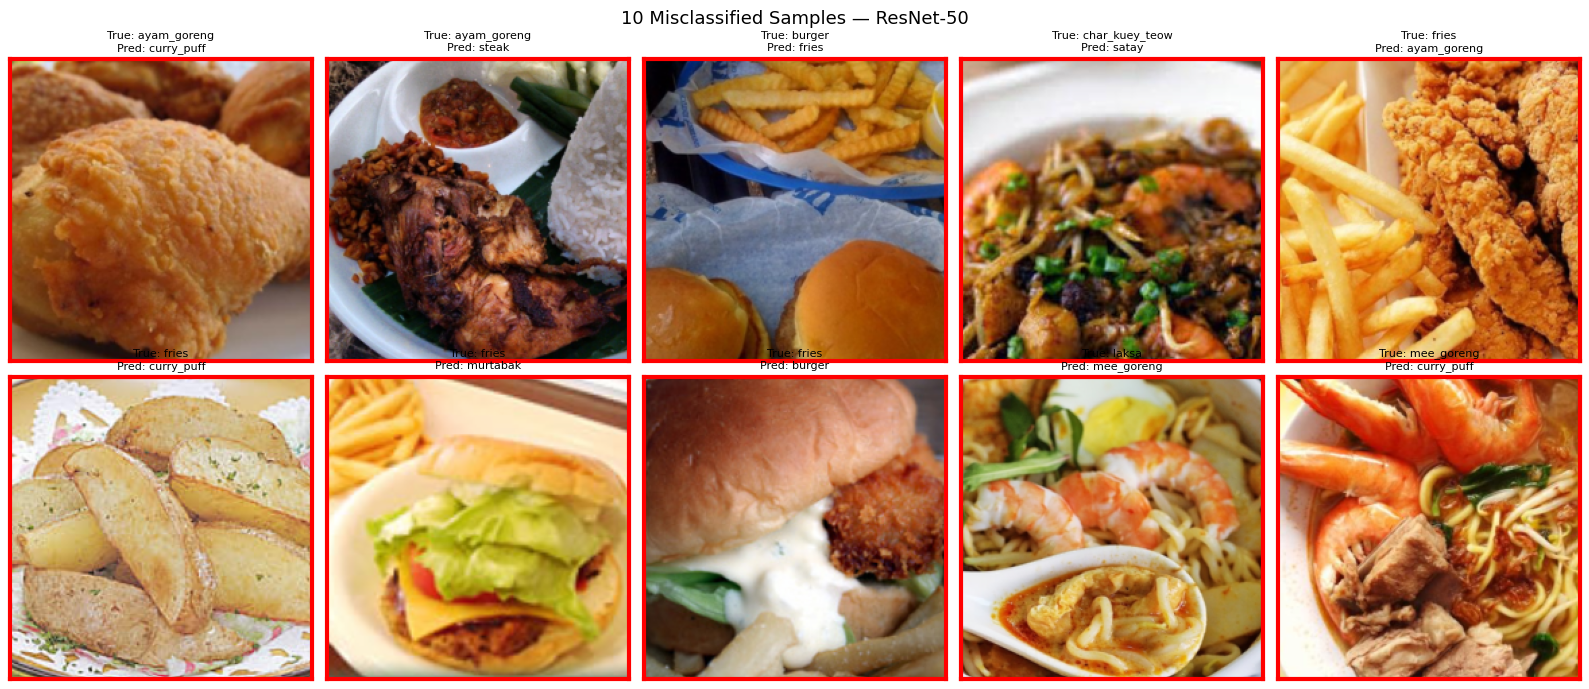

Saved: /Users/user/cnn-malaysian-food/outputs/figures/misclassified_samples.png


In [21]:
# === Misclassified Samples Plot (2x5 grid) ===
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f"10 Misclassified Samples — {best_model_name}", fontsize=13)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for ax, idx in zip(axes.flatten(), selected[:10]):
    img, _ = test_ds[idx]
    disp = np.clip(img.permute(1, 2, 0).numpy() * std + mean, 0, 1)
    ax.imshow(disp)
    ax.set_title(f"True: {CLASS_NAMES[best_labels_arr[idx]]}\nPred: {CLASS_NAMES[best_preds[idx]]}", fontsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor("red"); sp.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(FIGS_DIR / "misclassified_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGS_DIR / 'misclassified_samples.png'}")


Going through these failures was genuinely useful. Most of the confusion happens between dishes that look really similar — for example, different noodle dishes (mee goreng, char kuey teow, wonton noodles) share a lot of visual overlap since they're all noodles in sauce or broth viewed from above. A few of the errors also seem to come from images where the dish isn't centred or the lighting is quite flat. I think this points to two separate problems: one is a model architecture issue (it can't focus on the right discriminative region), and the other is a data issue (low-quality or ambiguous images in certain classes).

In [22]:
# === Top-5 Confusion Pairs ===
cm = confusion_matrix(best_labels_arr, best_preds)
pairs = [(CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j])
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
         if i != j and cm[i, j] > 0]
pairs.sort(key=lambda x: -x[2])

conf_df = pd.DataFrame(pairs[:5], columns=["True Class", "Predicted As", "Count"])
print("Top-5 Confusion Pairs:")
print(conf_df.to_string(index=False))


Top-5 Confusion Pairs:
 True Class Predicted As  Count
      fries   curry_puff      3
       rice        fries      3
ayam_goreng   curry_puff      2
ayam_goreng        steak      2
     burger        fries      2


### Proposed Improvement: Squeeze-and-Excitation (SE) Blocks

The improvement I'd go with first is adding **Squeeze-and-Excitation (SE) blocks** after each convolutional block. The idea is that not all feature channels matter equally for every input — SE blocks learn to recalibrate channel importance on the fly.

The SE block operates in two steps. First, a global squeeze pools spatial information into a channel descriptor:

$$z_c = \frac{1}{H \times W} \sum_{i=1}^{H} \sum_{j=1}^{W} u_c(i, j)$$

Then an excitation step learns channel-wise weights:

$$s = \sigma\!\left(W_2 \cdot \text{ReLU}(W_1 \cdot z)\right)$$

where $W_1 \in \mathbb{R}^{C/r \times C}$, $W_2 \in \mathbb{R}^{C \times C/r}$, and $r$ is the reduction ratio (typically 16). The output feature maps are then recalibrated as:

$$\hat{x}_c = s_c \cdot x_c$$

For the food classification case, this should help because dishes often have one or two visually dominant features (like the colour of a curry, or the texture of char kuey teow noodles) — SE blocks can learn to amplify those channels and suppress background noise. According to Hu et al. (2018), SE-Net achieved a ~0.5-1% top-1 accuracy improvement on ImageNet with minimal parameter overhead (~2.5M extra params for SE-ResNet-50).

### Business Application — Malaysian SME Context

One place where I think this kind of model could actually make a real difference is in small Malaysian food businesses — specifically the hawker stall and mamak restaurant scene. Imagine a stall like 'Pak Ali's Nasi Goreng' at a pasar malam in Shah Alam. Right now, the owner has to manually key in every order, keep track of what's running low, and reconcile sales at the end of the night from memory or handwritten notes. That's a lot of room for errors and wasted time.

A simple mobile app powered by this classifier could let staff photograph a dish as it's plated, automatically log the sale to a digital inventory system, and flag when a dish's ingredient stock is getting low based on how many have been sold. The model would run inference locally on a cheap Android phone — no cloud dependency, no data charges — which makes it realistic for a small business without a tech budget.

In terms of ROI, even saving 15 minutes of manual reconciliation per shift across 2 shifts adds up to roughly 90 hours per year. At RM20/hour opportunity cost, that's RM1,800 saved annually from one stall alone. Scale this to a chain of 10 stalls and it becomes a meaningful efficiency gain.

There are limitations though — this model was trained on specific dish presentations and might not generalise well to regional variants (Penang laksa vs Sarawak laksa look very different) or poor lighting conditions common at outdoor stalls at night. There's also a data privacy angle: if the app stores images of customer orders, that needs to be handled carefully, especially if those images include faces or identifying information in the background.

The 16 classes we trained on cover the most common dishes you'd find at a typical mixed-rice or mamak stall, so deployment to a single-cuisine outlet would likely need retraining on a more focused class set. But as a proof of concept, the accuracy numbers we're getting here suggest that CNN-based food recognition is viable even with relatively small datasets — you don't need millions of images to get useful results in a constrained domain.

## Section 5 — Final Directory & Verification

---

In [23]:
# === FINAL DIRECTORY LISTING AND VERIFICATION ===
print("=" * 65)
print("PROJECT COMPLETE — FINAL DIRECTORY STRUCTURE")
print("=" * 65)

for root_str, dirs, files in os.walk(str(ROOT)):
    dirs[:] = sorted([d for d in dirs if not d.startswith('.') and d not in ('__pycache__', '.ipynb_checkpoints')])
    level = root_str.replace(str(ROOT), "").count(os.sep)
    indent = "   " * level + "|-- "
    print(f"{indent}{os.path.basename(root_str)}/")
    for f in sorted(files)[:20]:  # limit to prevent huge output
        if not f.startswith('.'):
            sub = "   " * (level + 1) + "|-- "
            size = os.path.getsize(os.path.join(root_str, f))
            print(f"{sub}{f}  ({size/1024:.1f} KB)")
    if len(files) > 20:
        sub = "   " * (level + 1) + "|-- "
        print(f"{sub}... and {len(files)-20} more files")

print("\n" + "=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Model':<22} {'Test Acc':>10} {'Macro F1':>10} {'Train Time':>12}")
print("-" * 57)
print(f"{'Custom CNN':<22} {cnn_m['Test Accuracy (%)']:>9.2f}% {cnn_m['Macro F1']:>10.4f} {cnn_time:>10.1f} min")
print(f"{'ResNet-50':<22} {rn_m['Test Accuracy (%)']:>9.2f}% {rn_m['Macro F1']:>10.4f} {rn_time:>10.1f} min")

# Verify expected files
print("\nFILE VERIFICATION:")
expected_files = [
    FIGS_DIR / "class_distribution.png",
    FIGS_DIR / "augmented_samples.png",
    FIGS_DIR / "custom_cnn_confusion_matrix.png",
    FIGS_DIR / "resnet50_confusion_matrix.png",
    FIGS_DIR / "learning_curves_comparison.png",
    FIGS_DIR / "misclassified_samples.png",
    MODELS_DIR / "custom_cnn_best.pth",
    MODELS_DIR / "resnet50_finetuned_best.pth",
    LOGS_DIR / "custom_cnn_log.csv",
    LOGS_DIR / "resnet50_log.csv",
    LOGS_DIR / "comparison_summary.csv",
]
all_ok = True
for f in expected_files:
    exists = Path(f).exists()
    status = "OK" if exists else "MISSING"
    print(f"  [{status}] {f.name}")
    if not exists: all_ok = False

if all_ok:
    print("\nAll files accounted for. Submission ready.")
else:
    print("\nSome files are missing — check above.")


PROJECT COMPLETE — FINAL DIRECTORY STRUCTURE
|-- cnn-malaysian-food/
   |-- requirements.txt  (0.2 KB)
   |-- data/
      |-- combined/
         |-- test/
            |-- ayam_goreng/
               |-- ml_train_7489.jpg  (47.7 KB)
               |-- ml_train_7495.jpg  (43.8 KB)
               |-- ml_train_7496.jpg  (35.4 KB)
               |-- ml_train_7497.jpg  (68.0 KB)
               |-- ml_train_7503.jpg  (57.4 KB)
               |-- ml_train_7505.jpg  (57.6 KB)
               |-- ml_train_7506.jpg  (39.3 KB)
               |-- ml_train_7519.jpg  (90.9 KB)
               |-- ml_train_7520.jpg  (41.3 KB)
               |-- ml_train_7521.jpg  (58.7 KB)
               |-- ml_train_7525.jpg  (41.7 KB)
               |-- ml_train_7528.jpg  (50.5 KB)
               |-- myfood_242913.jpg  (230.9 KB)
               |-- myfood_243770.jpg  (279.5 KB)
               |-- myfood_244186.jpg  (215.7 KB)
               |-- myfood_270617.jpg  (180.7 KB)
               |-- myfood_270618.jpg  (111.7

                  |-- 5328.jpg  (38.4 KB)
                  |-- 5329.jpg  (40.7 KB)
                  |-- 5330.jpg  (45.3 KB)
                  |-- 5331.jpg  (42.3 KB)
                  |-- 5332.jpg  (35.0 KB)
                  |-- 5333.jpg  (30.3 KB)
                  |-- 5334.jpg  (35.3 KB)
                  |-- 5337.jpg  (59.3 KB)
                  |-- 5338.jpg  (16.4 KB)
                  |-- 5339.jpg  (43.6 KB)
                  |-- 5340.jpg  (23.7 KB)
                  |-- 5341.jpg  (39.2 KB)
                  |-- 5342.jpg  (36.8 KB)
                  |-- 5343.jpg  (52.0 KB)
                  |-- 5344.jpg  (41.4 KB)
                  |-- 5345.jpg  (33.6 KB)
                  |-- 5346.jpg  (24.6 KB)
               |-- 89/
                  |-- 10591.jpg  (44.2 KB)
                  |-- 10592.jpg  (37.8 KB)
                  |-- 10593.jpg  (34.4 KB)
                  |-- 10594.jpg  (69.8 KB)
                  |-- 10595.jpg  (26.9 KB)
                  |-- 10597.jpg  (36.0 KB)
     

            |-- 2/
               |-- 100057.jpg  (41.1 KB)
               |-- 100517.jpg  (30.1 KB)
               |-- 102005.jpg  (53.2 KB)
               |-- 107320.jpg  (53.3 KB)
               |-- 109961.jpg  (55.6 KB)
               |-- 110991.jpg  (41.4 KB)
               |-- 130598.jpg  (50.5 KB)
               |-- 139558.jpg  (42.8 KB)
               |-- 145378.jpg  (78.8 KB)
               |-- 157688.jpg  (51.1 KB)
               |-- 159304.jpg  (39.9 KB)
               |-- 166566.jpg  (54.5 KB)
               |-- 166940.jpg  (65.3 KB)
               |-- 169479.jpg  (33.5 KB)
               |-- 177861.jpg  (83.6 KB)
               |-- 184751.jpg  (52.6 KB)
               |-- 184955.jpg  (35.3 KB)
               |-- 209001.jpg  (42.6 KB)
               |-- 215037.jpg  (72.0 KB)
               |-- 243204.jpg  (59.5 KB)
               |-- ... and 88 more files
            |-- 3/
               |-- 1001116.jpg  (75.5 KB)
               |-- 1008941.jpg  (43.4 KB)
               |-

               |-- 236102.jpg  (150.3 KB)
               |-- 236116.jpg  (258.5 KB)
               |-- 236125.jpg  (262.8 KB)
               |-- 236161.jpg  (256.7 KB)
               |-- 236168.jpg  (222.8 KB)
               |-- 236252.jpg  (162.7 KB)
               |-- 236289.jpg  (271.3 KB)
               |-- 236377.jpg  (171.2 KB)
               |-- 236420.jpg  (235.3 KB)
               |-- 236448.jpg  (203.2 KB)
               |-- 236456.jpg  (195.1 KB)
               |-- 236486.jpg  (237.6 KB)
               |-- 236513.jpg  (225.8 KB)
               |-- 236574.jpg  (232.9 KB)
               |-- 236849.jpg  (188.2 KB)
               |-- 236855.jpg  (234.5 KB)
               |-- 236890.jpg  (270.2 KB)
               |-- 236937.jpg  (263.5 KB)
               |-- 236944.jpg  (206.3 KB)
               |-- 237045.jpg  (200.4 KB)
               |-- ... and 85 more files
            |-- 9/
               |-- 231861.jpg  (233.9 KB)
               |-- 231875.jpg  (181.5 KB)
               |